## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on datasets. **
2. Apply required **data preprocessing** steps:

   * Handling missing values **
   * Feature encoding (if applicable) **
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, recall_score
import statsmodels.api as sm 
from sklearn.linear_model import LinearRegression, LogisticRegression

# %matplotlib inline


In [141]:
df1 = pd.read_csv("../Dataset/housing.csv")

df1["rooms_per_household"]      = df1["total_rooms"] / df1["households"]
df1["bedrooms_per_room"]        = df1["total_bedrooms"] / df1["total_rooms"]
df1["population_per_household"] = df1["population"] / df1["households"]
df1 = df1.drop(columns=["total_rooms", "total_bedrooms"])
df1.head()

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [142]:
df1.shape

(20640, 11)

In [143]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   population                20640 non-null  float64
 4   households                20640 non-null  float64
 5   median_income             20640 non-null  float64
 6   median_house_value        20640 non-null  float64
 7   ocean_proximity           20640 non-null  str    
 8   rooms_per_household       20640 non-null  float64
 9   bedrooms_per_room         20433 non-null  float64
 10  population_per_household  20640 non-null  float64
dtypes: float64(10), str(1)
memory usage: 1.7 MB


In [144]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
households,20640.0,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_value,20640.0,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000
rooms_per_household,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
bedrooms_per_room,20433.0,0.213039,0.057983,0.100000,0.175427,0.203162,0.239821,1.000000
population_per_household,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333


In [145]:
df1.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

In [146]:
df1.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [147]:
df1['bedrooms_per_room']= df1.bedrooms_per_room.fillna(df1.bedrooms_per_room.median())
df1.isnull().sum()

longitude                   0
latitude                    0
housing_median_age          0
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64

In [148]:
df1.duplicated().sum()

np.int64(0)

In [149]:
df1["ocean_proximity"].value_counts() #for non numeric data read

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'rooms_per_household'}>,
        <Axes: title={'center': 'bedrooms_per_room'}>],
       [<Axes: title={'center': 'population_per_household'}>, <Axes: >,
        <Axes: >]], dtype=object)

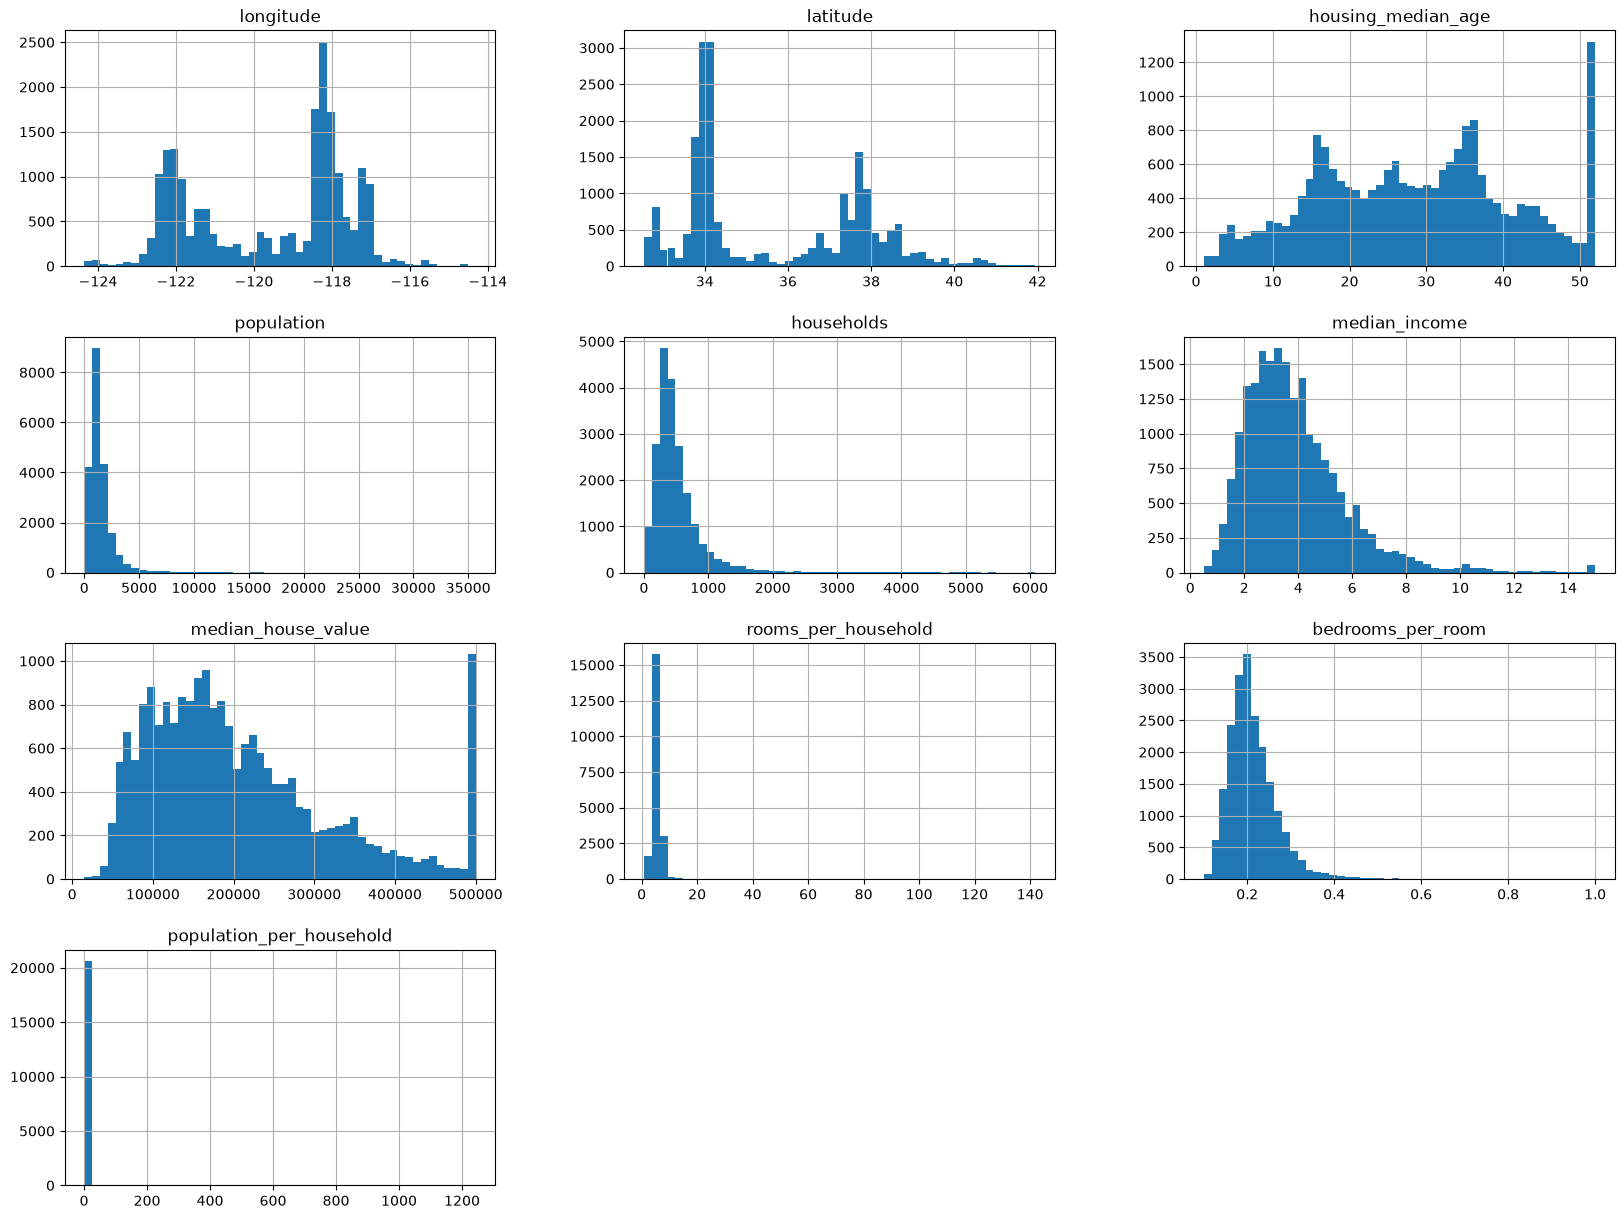

In [150]:
df1.hist(bins=50, figsize=(20,15))

### what alpha does:
Gives us a more precise idea about which area is densely packed with houses. Alpha means transparency of the plots. without alpha, each plot would be weighted the same and you wouldnt have any idea regarding the density.

Text(0.5, 1.0, 'Scatter Plot of California')

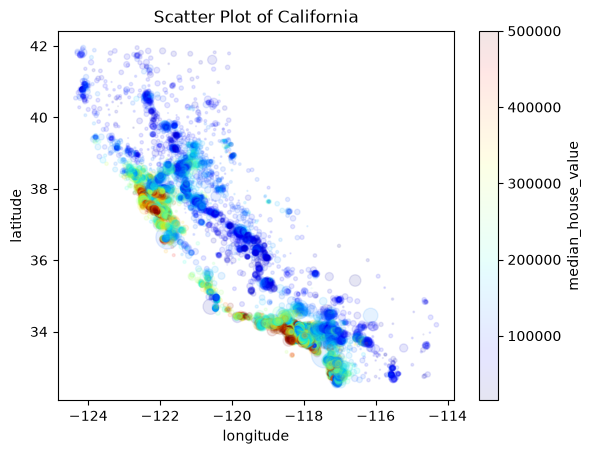

In [151]:
df1.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, 
         s=df1["population"]/100,
         c="median_house_value",
         cmap=plt.get_cmap("jet")
         )
plt.title("Scatter Plot of California")

## Observation from above:
1. the s value dictates the  scatter plot size vary based on the number of observed counts; higher the count, larger the dot
2. c dictates the color be varied based on the median, where cmap "jet" gives the heatmap kind of color. Here, blue tends to be lower priced while red higher
3. Observation shows that, the area in the bay have houses that are priced higher while the inland areas have fewer, cheaper blocks

In [152]:
corr_matrix= df1.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
housing_median_age          0.105623
households                  0.065843
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.254632
Name: median_house_value, dtype: float64

In [153]:
#One-Hot Encoding
dummies= pd.get_dummies(df1.ocean_proximity)
dummies= dummies.astype(int) # making 0s and 1s instead of T/F
housing_dummies= pd.concat([df1, dummies], axis="columns")
housing_dummies.head()


,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,0,0,0,1,0
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,0,0,0,1,0
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,0,0,0,1,0
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,0,0,0,1,0
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,0,0,0,1,0


We now drop some variables that are redundant (ocean proximity) or cause multi colinearity issues (Island)

In [154]:
housing_cleaned= housing_dummies.drop(['ocean_proximity', 'ISLAND'], axis= 'columns')
housing_cleaned.head()

,longitude,latitude,housing_median_age,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,0,0,1,0
1,-122.22,37.86,21.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,0,0,1,0
2,-122.24,37.85,52.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,0,0,1,0
3,-122.25,37.85,52.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,0,0,1,0
4,-122.25,37.85,52.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,0,0,1,0


In [155]:
X= housing_cleaned.drop(columns=["median_house_value"]) #removing median house value as the house price is what we're predicting
X.head()

y=housing_cleaned["median_house_value"]
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [156]:
#Split train test
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=2003) #x= featured, y= labelled, test size 20%

In [157]:
num_cols= ['longitude',
 'latitude',
 'housing_median_age',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

scaler= StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols]  = scaler.transform(X_test[num_cols])

In [158]:

OLS = LinearRegression() #just to make it easier to type instead of LinearRegression

OLS.fit(X_train, y_train) #x,y split because all the columns in x is what causes change in y, the median house price

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ -26932.56, -25773.96, 1060. ,...,-170157.77,-137259.37,-131243.78]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['longitude','latitude','housing_median_age',...,'INLAND','NEAR BAY', 'NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.22e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [159]:
print ("Intercept is "+str(OLS.intercept_)) #intercept and coefficients of the OLS model

print ("The set of coefficients are "+str(OLS.coef_))

print("The r-squared value is "+ str(OLS.score(X_train, y_train)))

Intercept is -2220296.766235792
The set of coefficients are [-2.69325634e+04 -2.57739560e+04  1.05999710e+03 -3.94398552e+01
  1.30246589e+02  4.10535132e+04  3.09140248e+03  2.64498269e+05
  6.40376149e+01 -1.36014875e+05 -1.70157770e+05 -1.37259368e+05
 -1.31243779e+05]
The r-squared value is 0.6517998087015466


In [160]:
#predicitng with OLS

y_pred= OLS.predict(X_test) #basically the y will contain the predicted value based on the X_test
performance= pd.DataFrame({'PREDICTION': y_pred, 'ACTUAL VALUES':y_test}) #check how well the performance is 
performance['ERROR']= performance['ACTUAL VALUES']-performance['PREDICTION'] #residual= error here
performance.head()

,PREDICTION,ACTUAL VALUES,ERROR
14572,230502.149075,212000.0,-18502.149075
94,194533.597874,179200.0,-15333.597874
4408,194238.347247,150000.0,-44238.347247
10237,221666.866032,176300.0,-45366.866032
11376,241737.148864,152100.0,-89637.148864


In [161]:
#preparing data for plotting

performance.reset_index(drop=True, inplace= True) #inplace turns the random sampled index value into a new index
performance.reset_index( inplace= True)
performance.head()

,index,PREDICTION,ACTUAL VALUES,ERROR
0,0,230502.149075,212000.0,-18502.149075
1,1,194533.597874,179200.0,-15333.597874
2,2,194238.347247,150000.0,-44238.347247
3,3,221666.866032,176300.0,-45366.866032
4,4,241737.148864,152100.0,-89637.148864


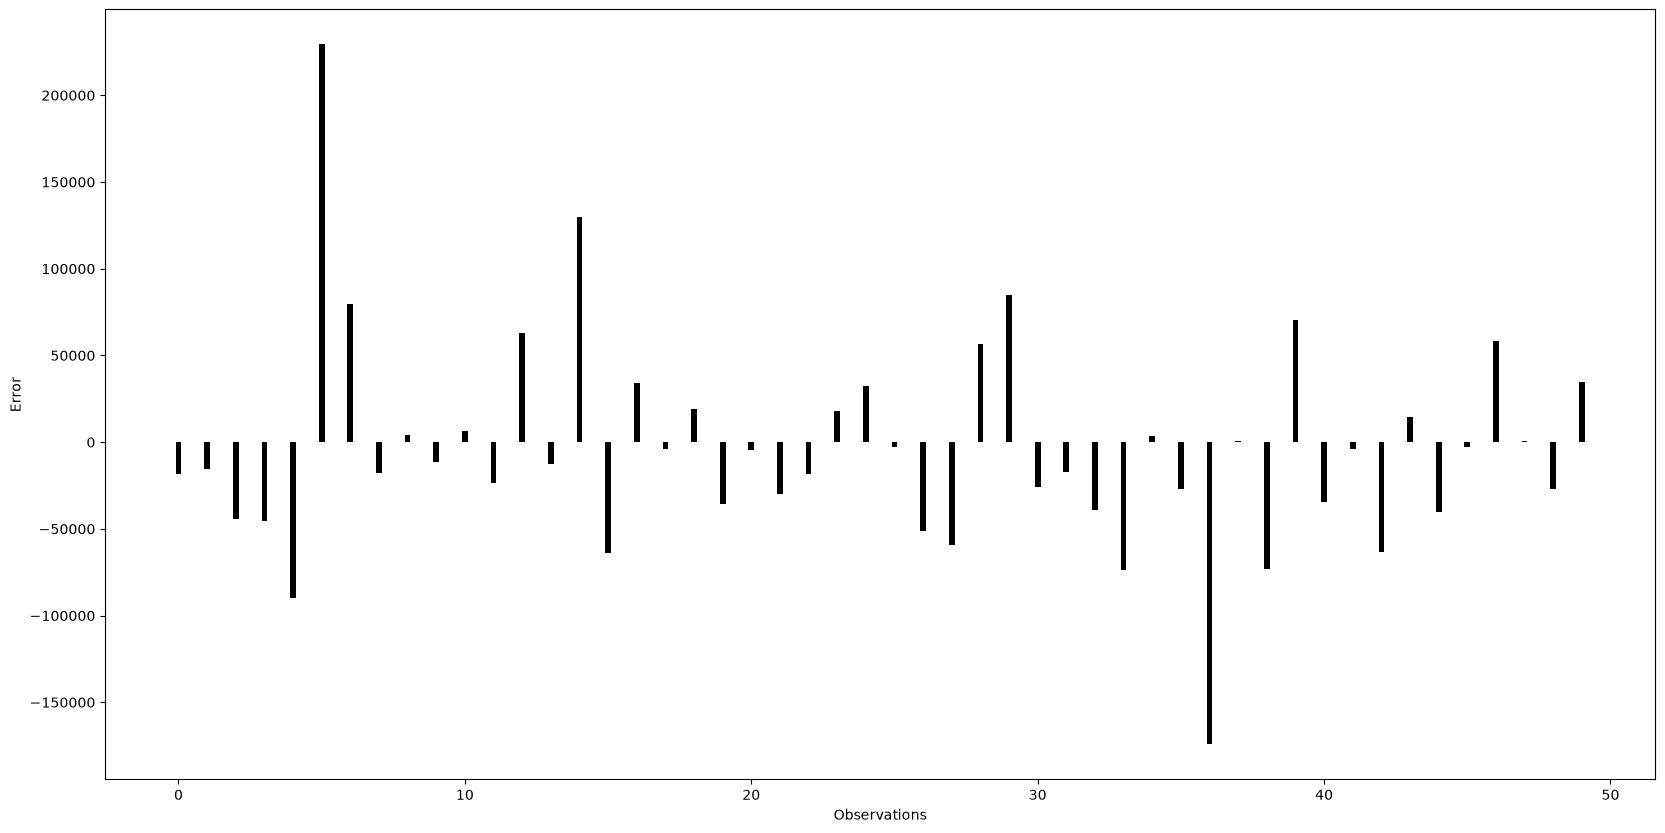

In [162]:
#plotting the error

fig = plt.figure(figsize=(20,10))
plt.bar('index', 'ERROR', data= performance[:50], color= 'black', width=0.2) # [:50] show the plot of the first 50 observations, width is the width of the bar
plt.xlabel("Observations")
plt.ylabel("Error")
plt.show()

In [163]:
# %pip install statsmodels

X_train= sm.add_constant(X_train) #step needed if you want your statsmodel result to be same as the linearregression model. just makes the data more readable with this
better_ols= sm.OLS(y_train, X_train).fit()
better_ols.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     2376.
Date:                Sun, 04 Oct 2026   Prob (F-statistic):               0.00
Time:                        20:47:08   Log-Likelihood:            -2.0714e+05
No. Observations:               16512   AIC:                         4.143e+05
Df Residuals:                   16498   BIC:                         4.144e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                     -2.22e+06   1.04e+05    -21.404      0.000   -2.42e+06   -2.02e+06
longitude                -2.693e+04   1124.204    -23.957      0.000   -2.91e+04   -2.47e+04
latitude                 -2.577e+04   1109.625    -23.228      0.000   -2.79e+04   -2.36e+04
housing_median_age        1059.9971     48.141     22.019      0.000     965.636    1154.358
population                 -39.4399      1.156    -34.107      0.000     -41.706     -37.173
households                 130.2466      3.483     37.392      0.000     123.419     137.074
median_income             4.105e+04    397.420    103.300      0.000    4.03e+04    4.18e+04
rooms_per_household       3091.4025    238.630     12.955      0.000    2623.663    3559.142
bedrooms_per_room         2.645e+05   1.27e+04     20.787      0.000     2.4e+05    2.89e+05
population_per_household    64.0376     47.057      1.361      0.174     -28.200     156.275
<1H OCEAN                 -1.36e+05    3.4e+04     -4.001      0.000   -2.03e+05   -6.94e+04
INLAND                   -1.702e+05   3.41e+04     -4.995      0.000   -2.37e+05   -1.03e+05
NEAR BAY                 -1.373e+05    3.4e+04     -4.033      0.000   -2.04e+05   -7.05e+04
NEAR OCEAN               -1.312e+05    3.4e+04     -3.859      0.000   -1.98e+05   -6.46e+04
==============================================================================
Omnibus:                     4047.850   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            17472.120
Skew:                           1.144   Prob(JB):                         0.00
Kurtosis:                       7.490   Cond. No.                     3.92e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.92e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [164]:
#how to get the MSE for this model

mse= mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
print(f"MSE: {mse:,.0f}  RMSE: {rmse:,.0f}")

MSE: 4,626,798,845  RMSE: 68,021


INTERPRETATION
- Linearity: mostly OK, with some curvature at high prices. Partially satisfied.
- Independence: DW near 2 is fine, but nearby blocks share similar prices
  (spatial correlation), so it is not perfectly independent in reality.
- Multicollinearity: total_rooms, total_bedrooms, population, households and
  longitude / latitude should show high VIF -> VIOLATED. This explains the odd negative coefficients.

POSSIBLE FIXES: drop the capped rows (y == 500001), log-transform the target,
replace the collinear columns with ratios (below)

## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

#### Why logistic regression for credic card default?

Because the give question classifies the result into 2 probabilistic categories - will he default on a payment or not.

In [165]:
credit_df= pd.read_csv("../Dataset/UCI_Credit_Card.csv")
credit_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [166]:
credit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [167]:
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [168]:
credit_df.isnull().sum().sum() # no null values in the dateset

np.int64(0)

In [169]:
credit_df.duplicated().sum() #  no duplicated entries in the dataset

np.int64(0)

In [170]:
credit_df.nunique()

ID                            30000
LIMIT_BAL                        81
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
PAY_5                            10
PAY_6                            10
BILL_AMT1                     22723
BILL_AMT2                     22346
BILL_AMT3                     22026
BILL_AMT4                     21548
BILL_AMT5                     21010
BILL_AMT6                     20604
PAY_AMT1                       7943
PAY_AMT2                       7899
PAY_AMT3                       7518
PAY_AMT4                       6937
PAY_AMT5                       6897
PAY_AMT6                       6939
default.payment.next.month        2
dtype: int64

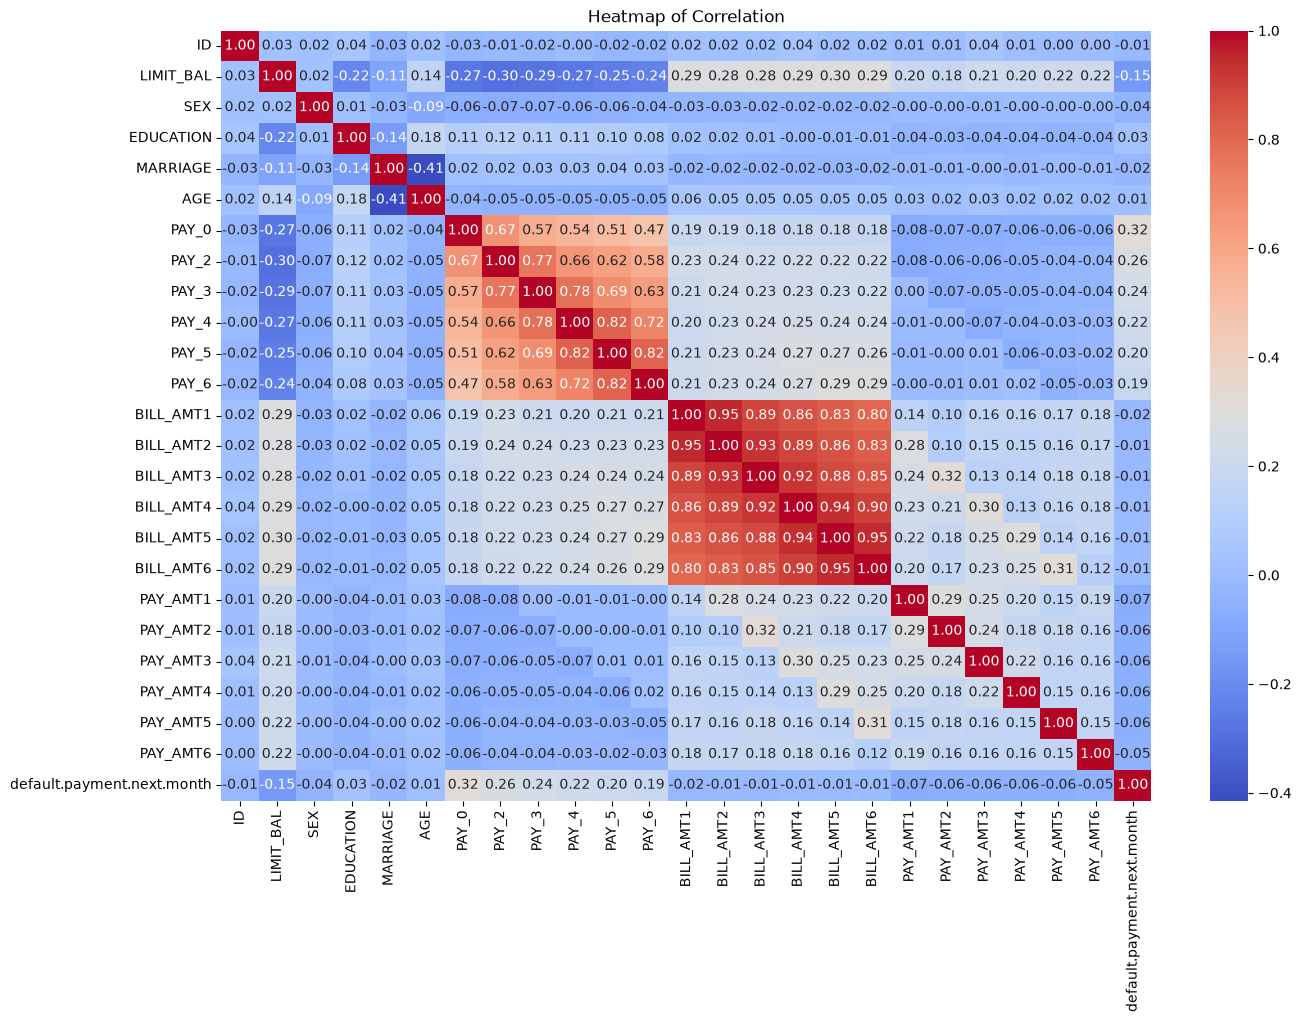

In [171]:
#EDA part
correlation_matrix= credit_df.corr()
plt.figure(figsize= (15,10))
sns.heatmap(correlation_matrix, annot=True, fmt ='.2f', cmap= 'coolwarm')
plt.title("Heatmap of Correlation")
plt.show()

In [172]:
credit_df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

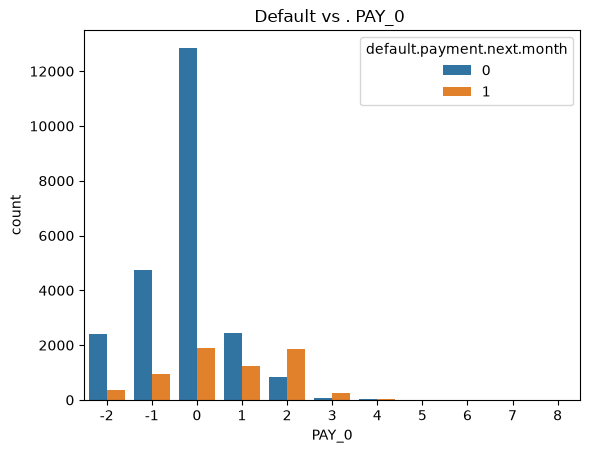

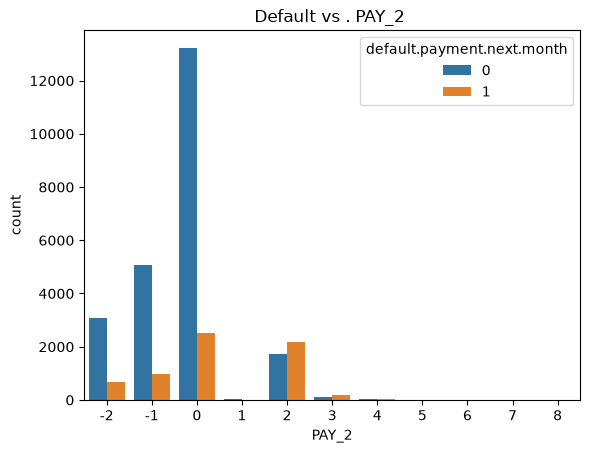

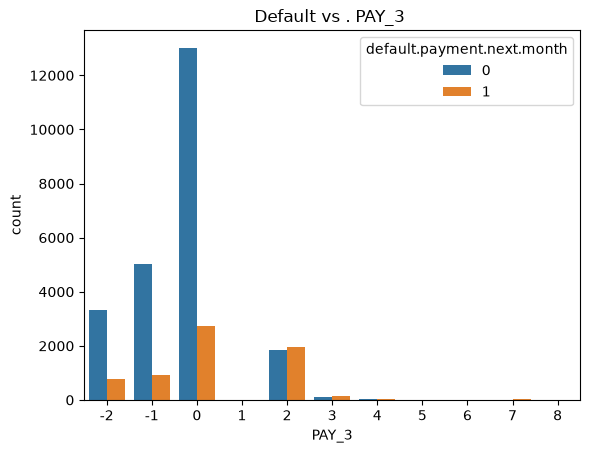

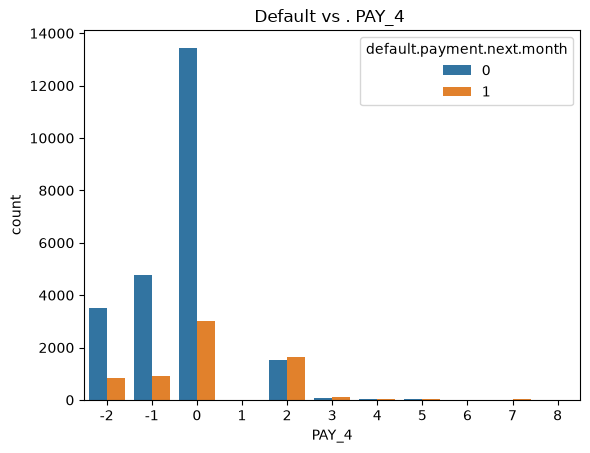

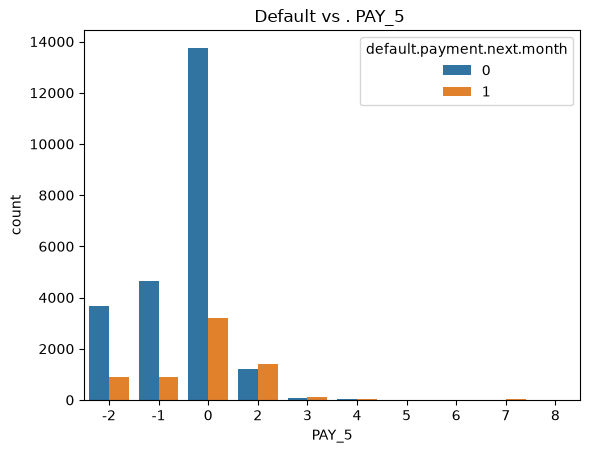

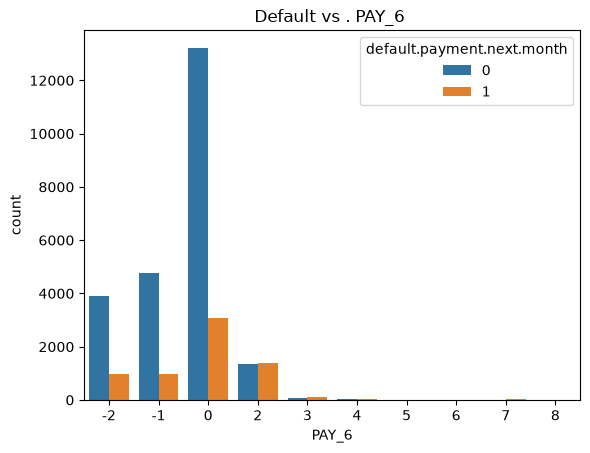

In [173]:
# payment_history_cols= [col for col in credit_df.columns if col.startswith("PAY_")]
payment_history_cols= ['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6']

for col in payment_history_cols:
    sns.countplot(x= col, hue= 'default.payment.next.month', data= credit_df)
    plt.title(f'Default vs . {col} ')
    plt.show()

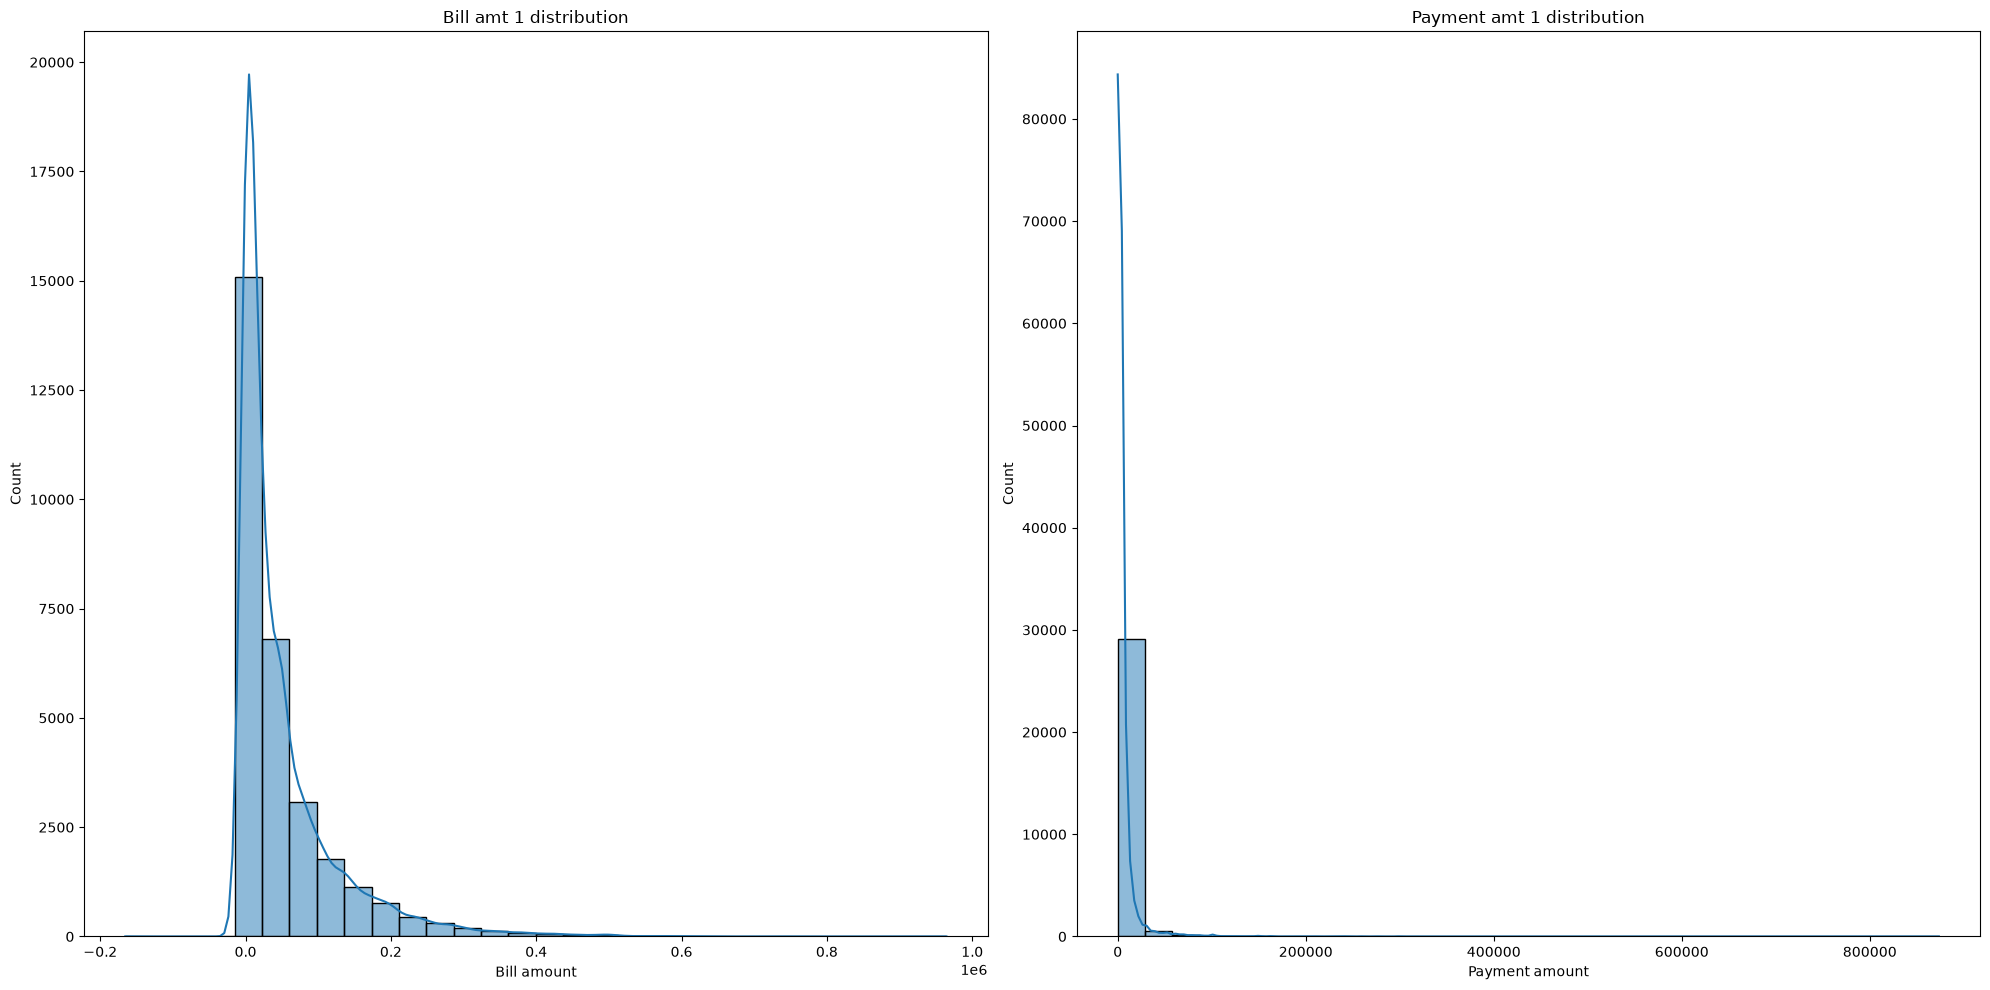

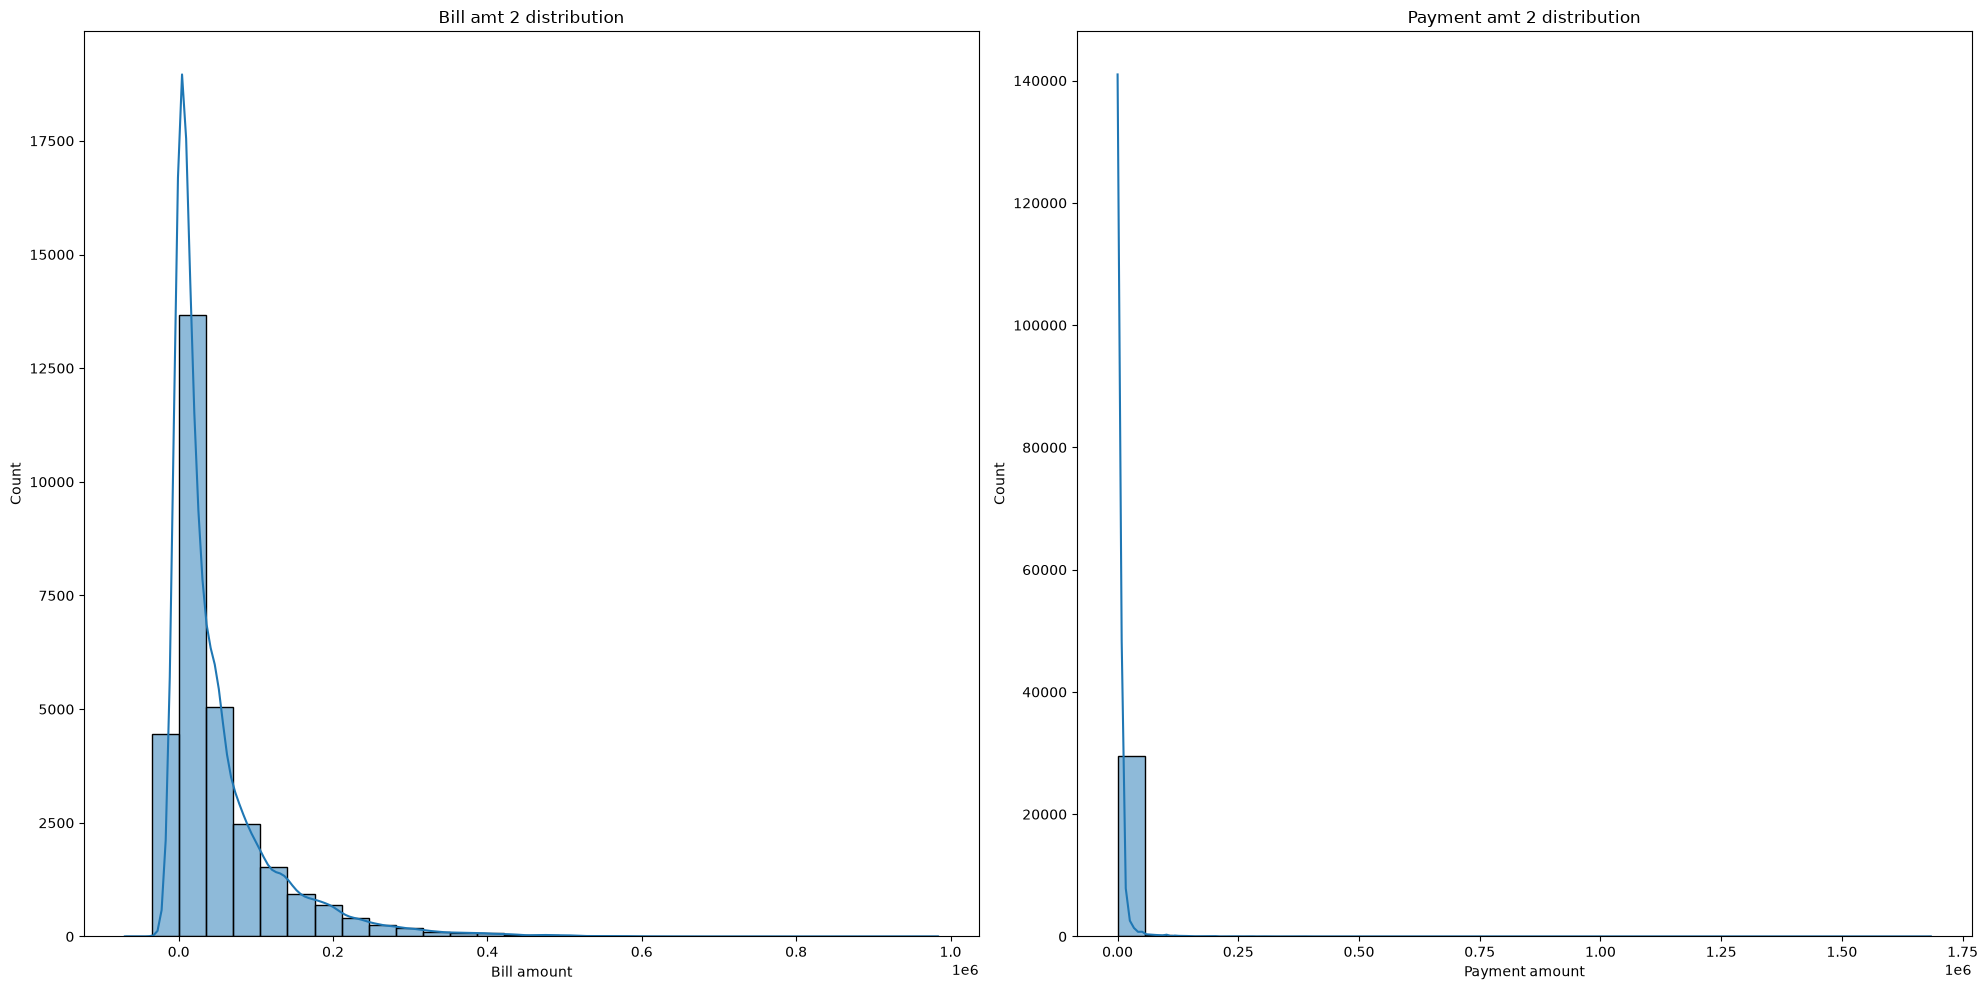

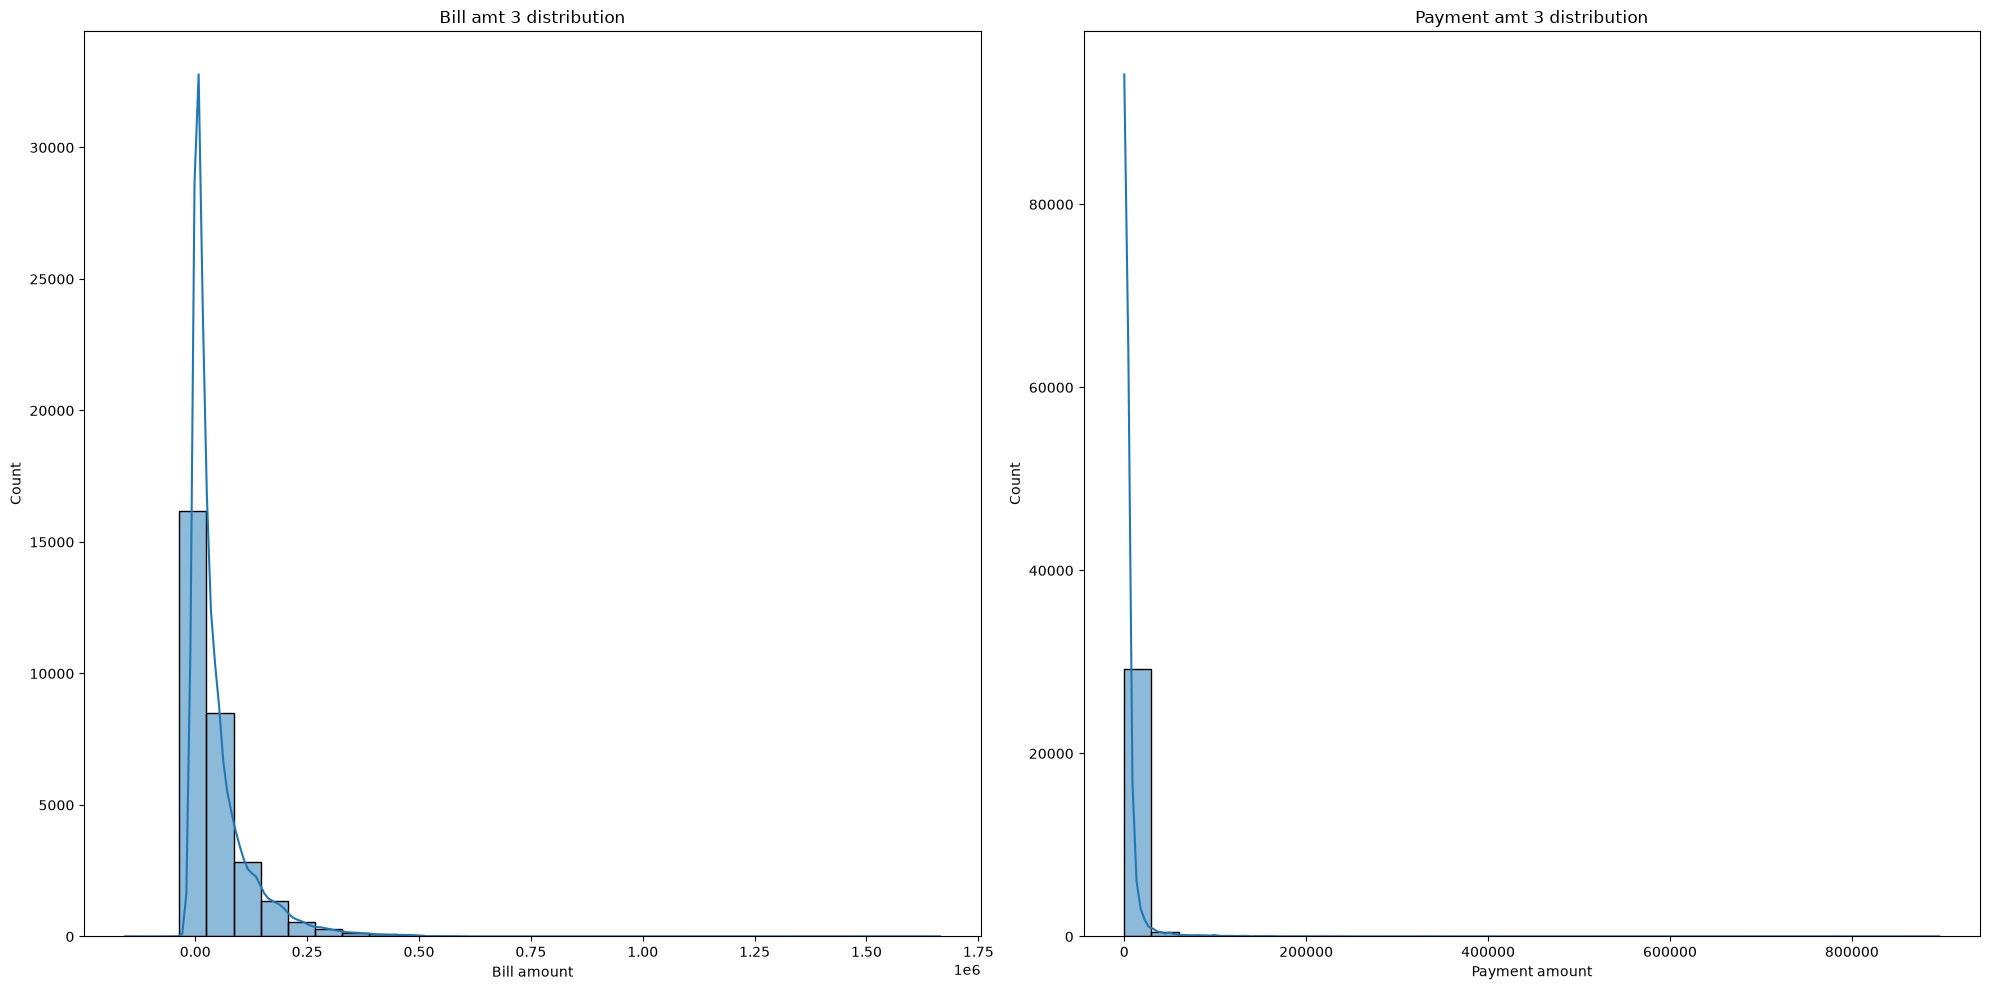

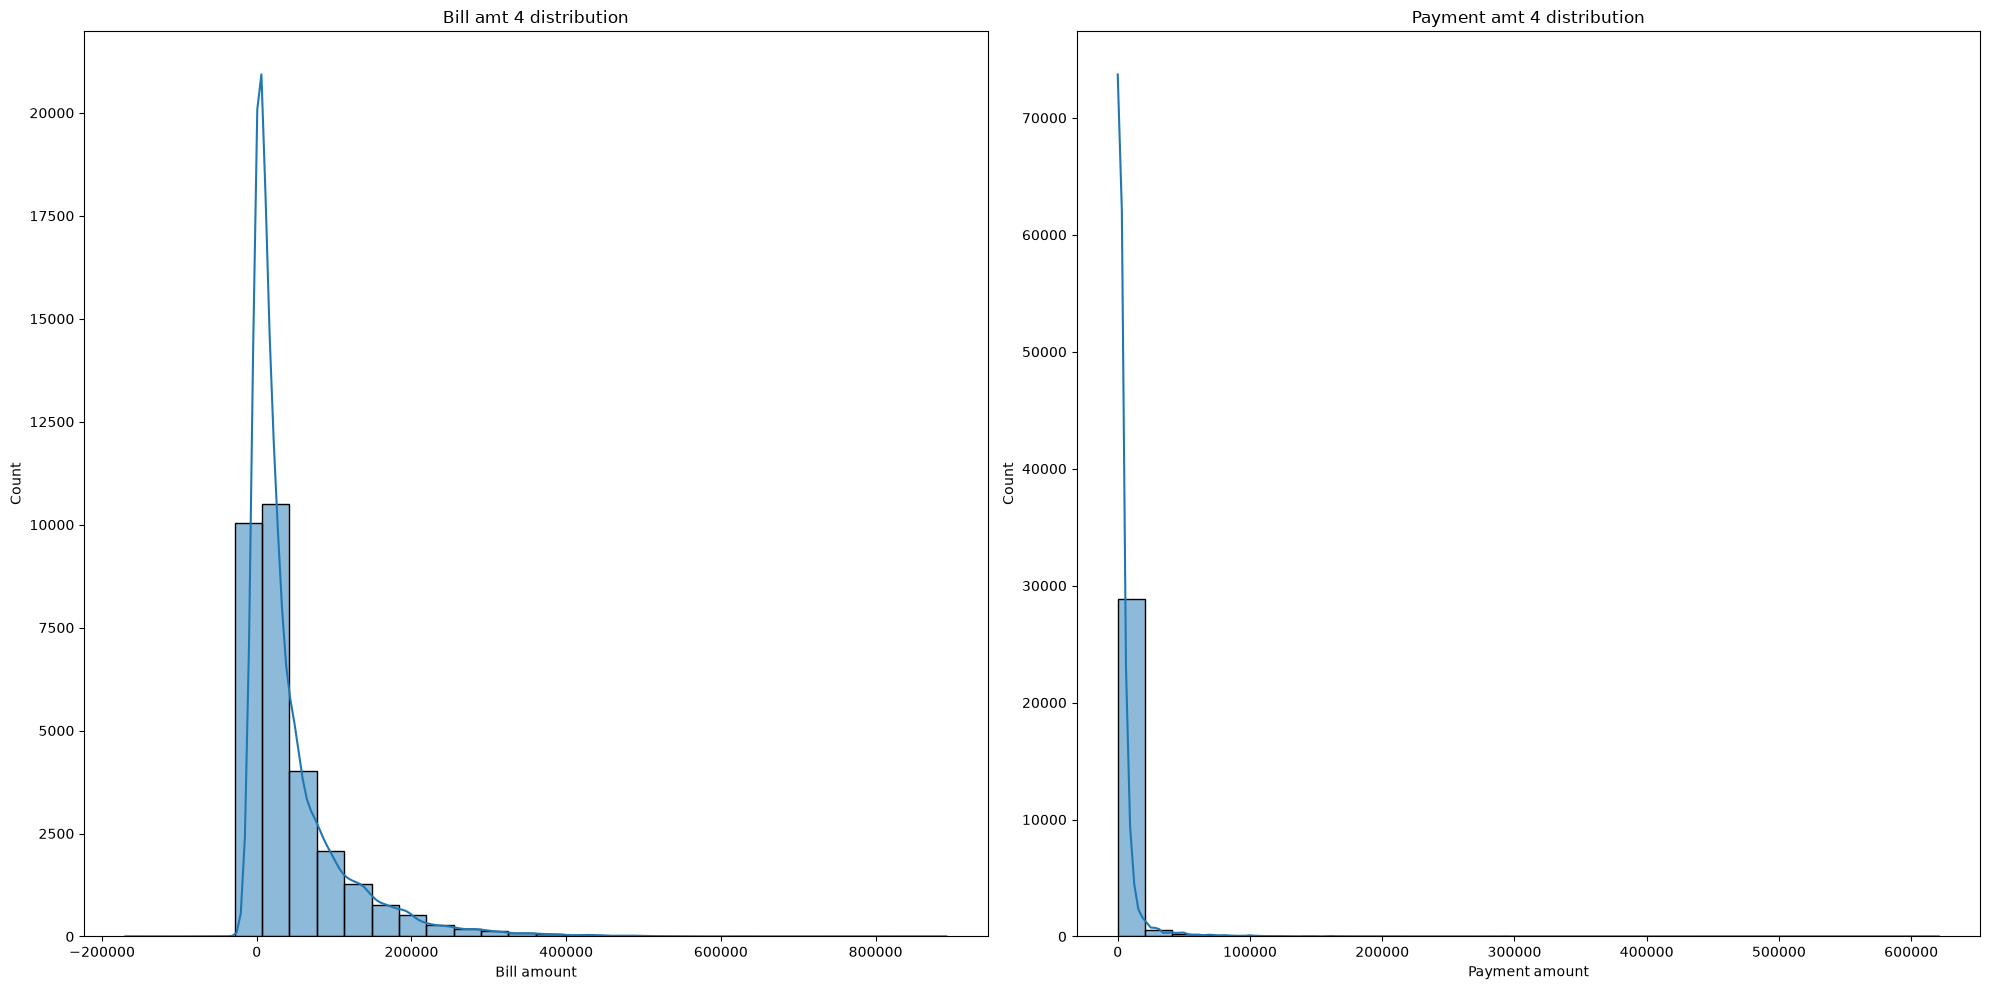

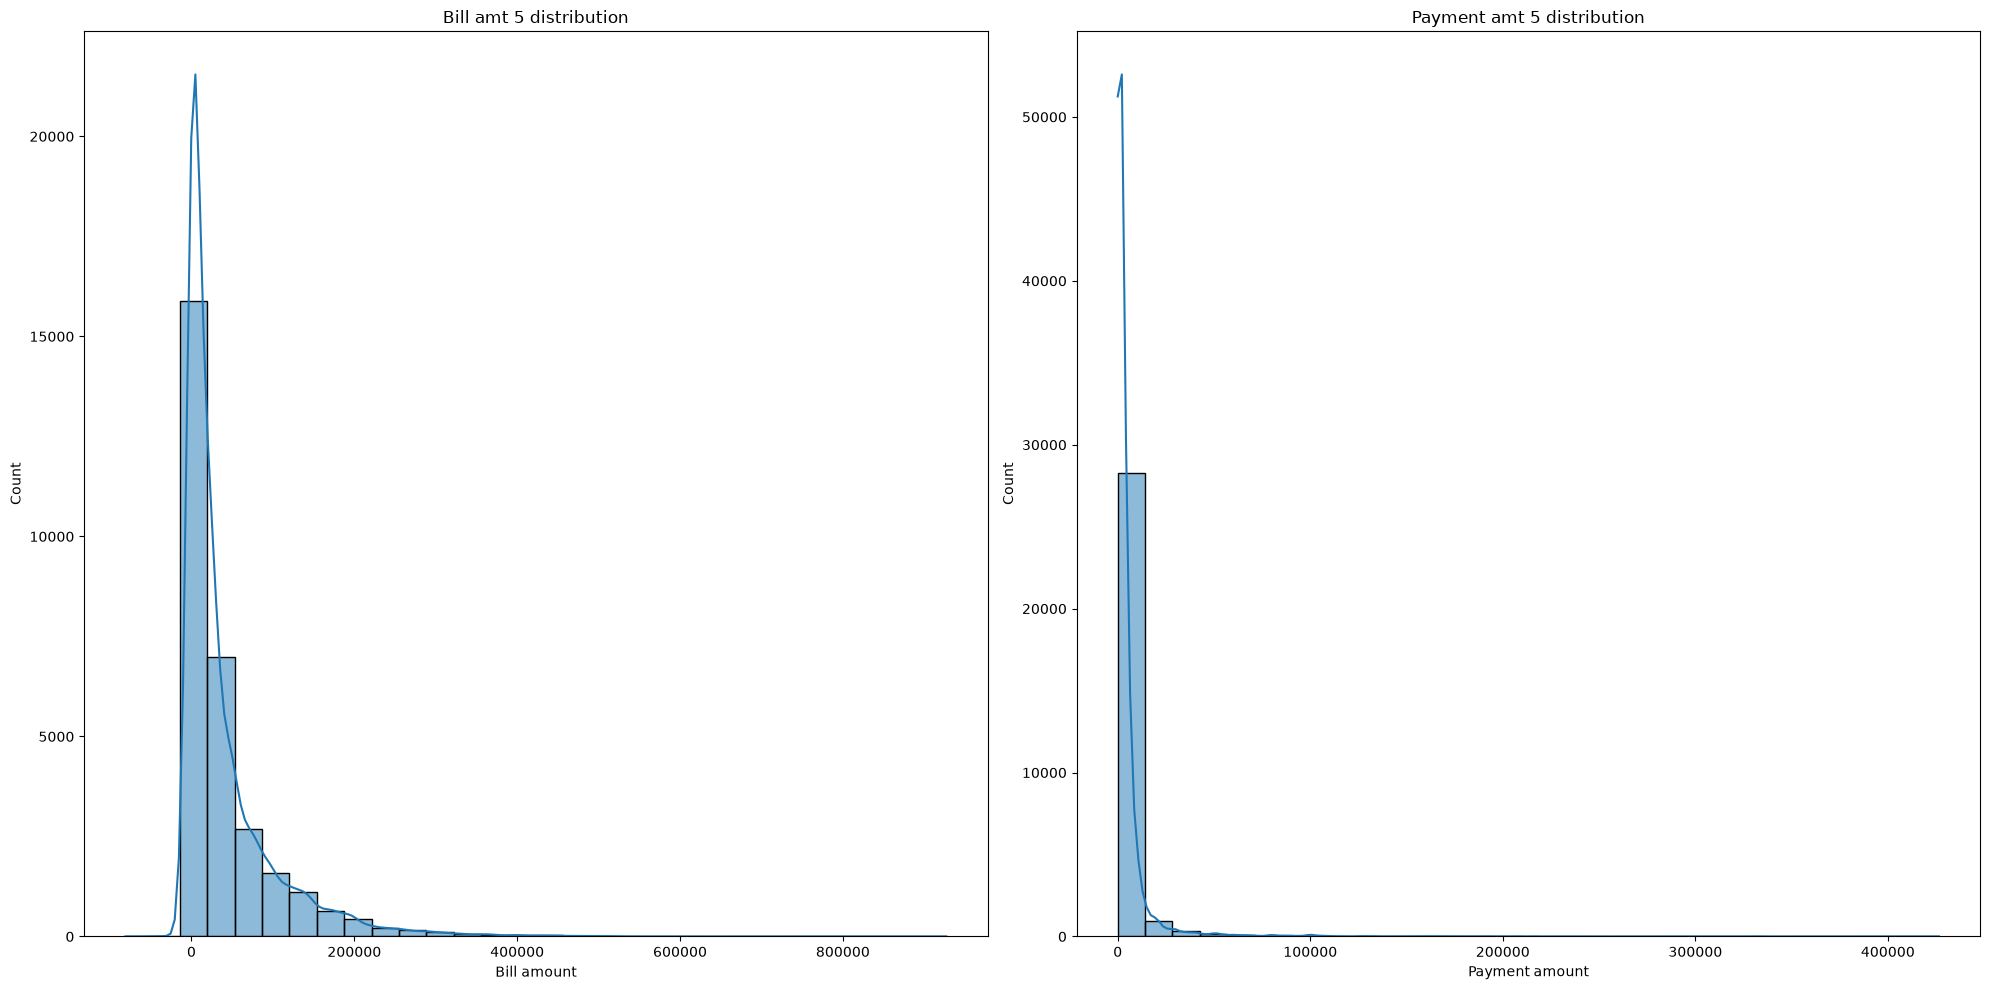

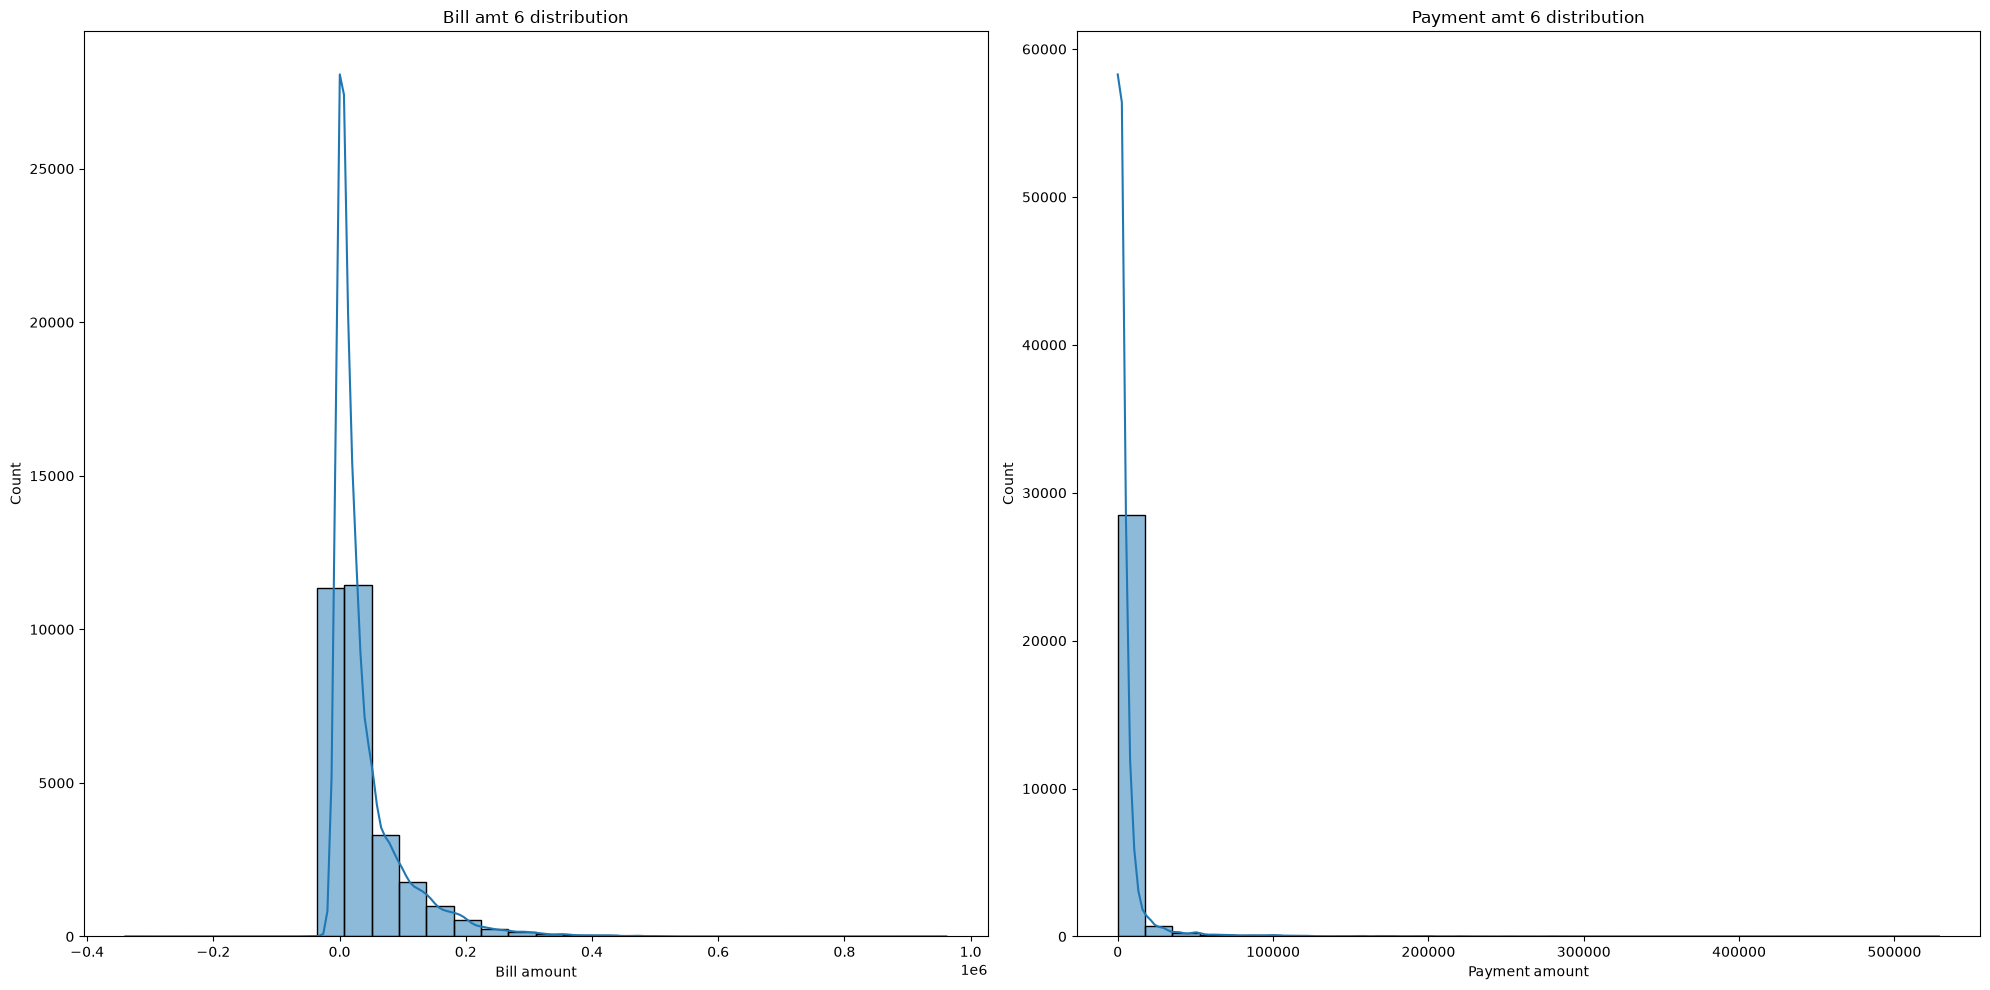

In [174]:
for i in range(1,7):
    plt.figure(figsize= (20,10))
    
    plt.subplot(1,2,1)
    sns.histplot(credit_df[f'BILL_AMT{i}'], bins= 30, kde= True)
    plt.title(f'Bill amt {i} distribution')
    plt.xlabel('Bill amount')
    plt.ylabel('Count')
    
    plt.subplot(1,2,2)
    sns.histplot(credit_df[f'PAY_AMT{i}'], bins= 30, kde= True)
    plt.title(f'Payment amt {i} distribution')
    plt.xlabel('Payment amount')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

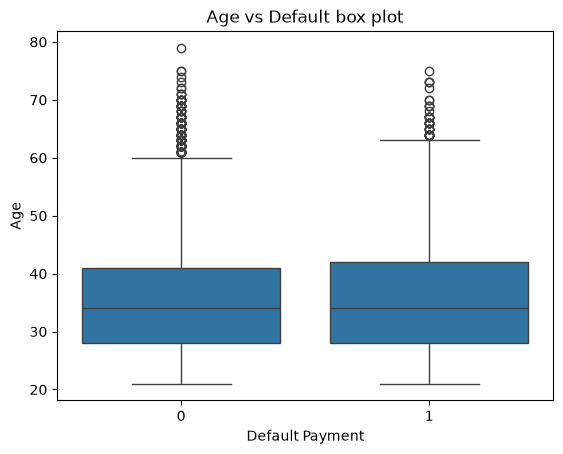

In [175]:
sns.boxplot(x= 'default.payment.next.month', y= 'AGE', data=credit_df)
plt.title('Age vs Default box plot')
plt.xlabel('Default Payment')
plt.ylabel('Age')
plt.show()


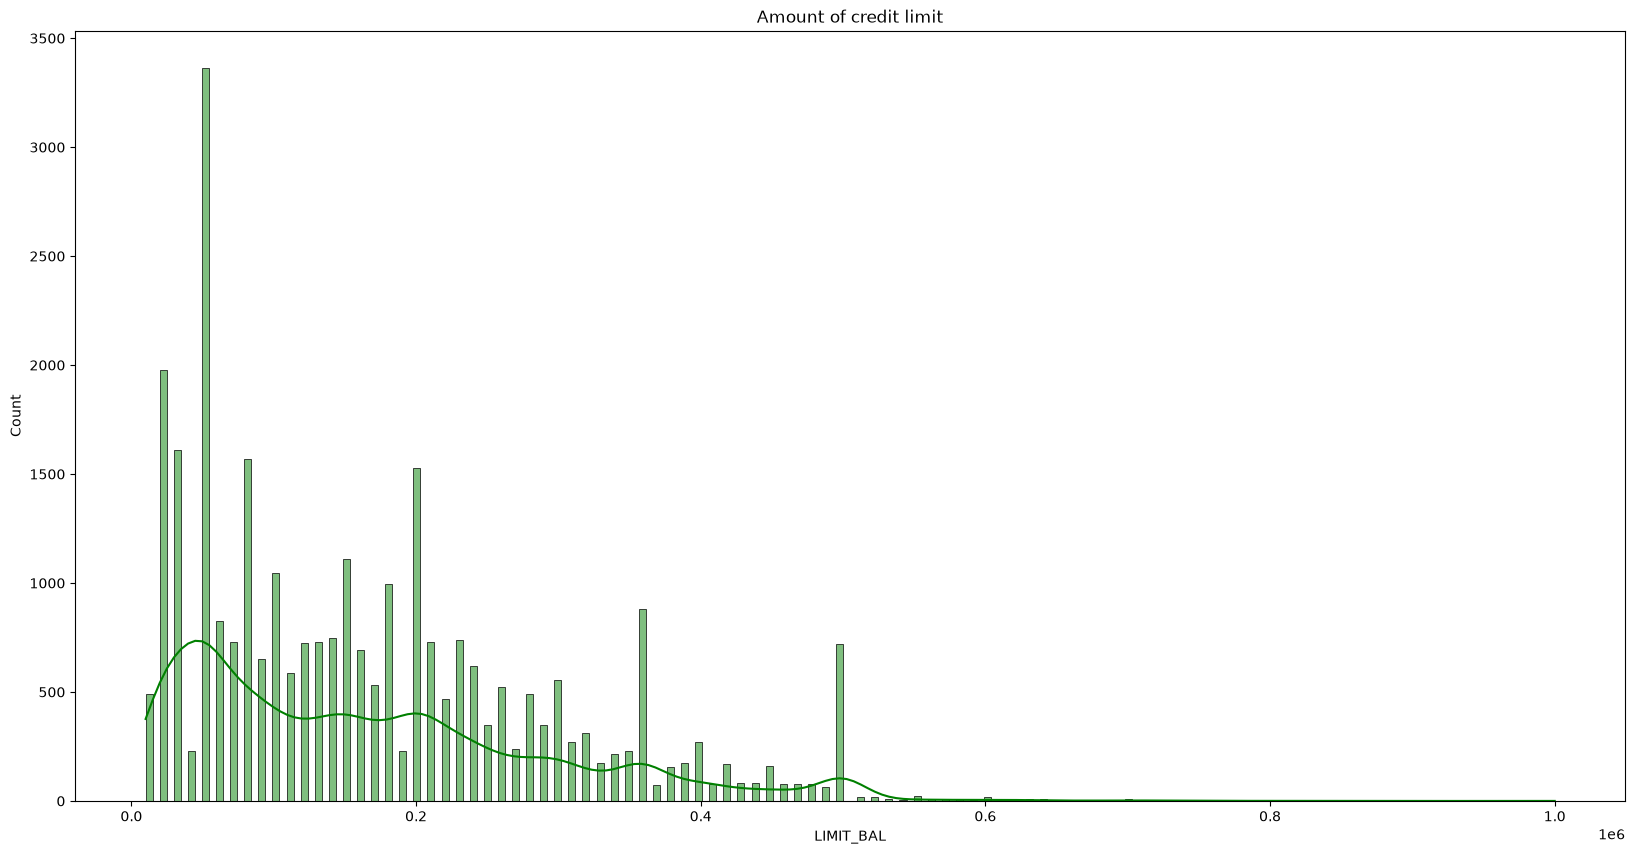

In [176]:
plt.figure(figsize=(20,10))
plt.title('Amount of credit limit')
sns.histplot(credit_df['LIMIT_BAL'], kde= True, bins=200, color='green')
plt.show()

In [177]:
credit_df['LIMIT_BAL'].value_counts().head(5)

LIMIT_BAL
50000.0     3365
20000.0     1976
30000.0     1610
80000.0     1567
200000.0    1528
Name: count, dtype: int64

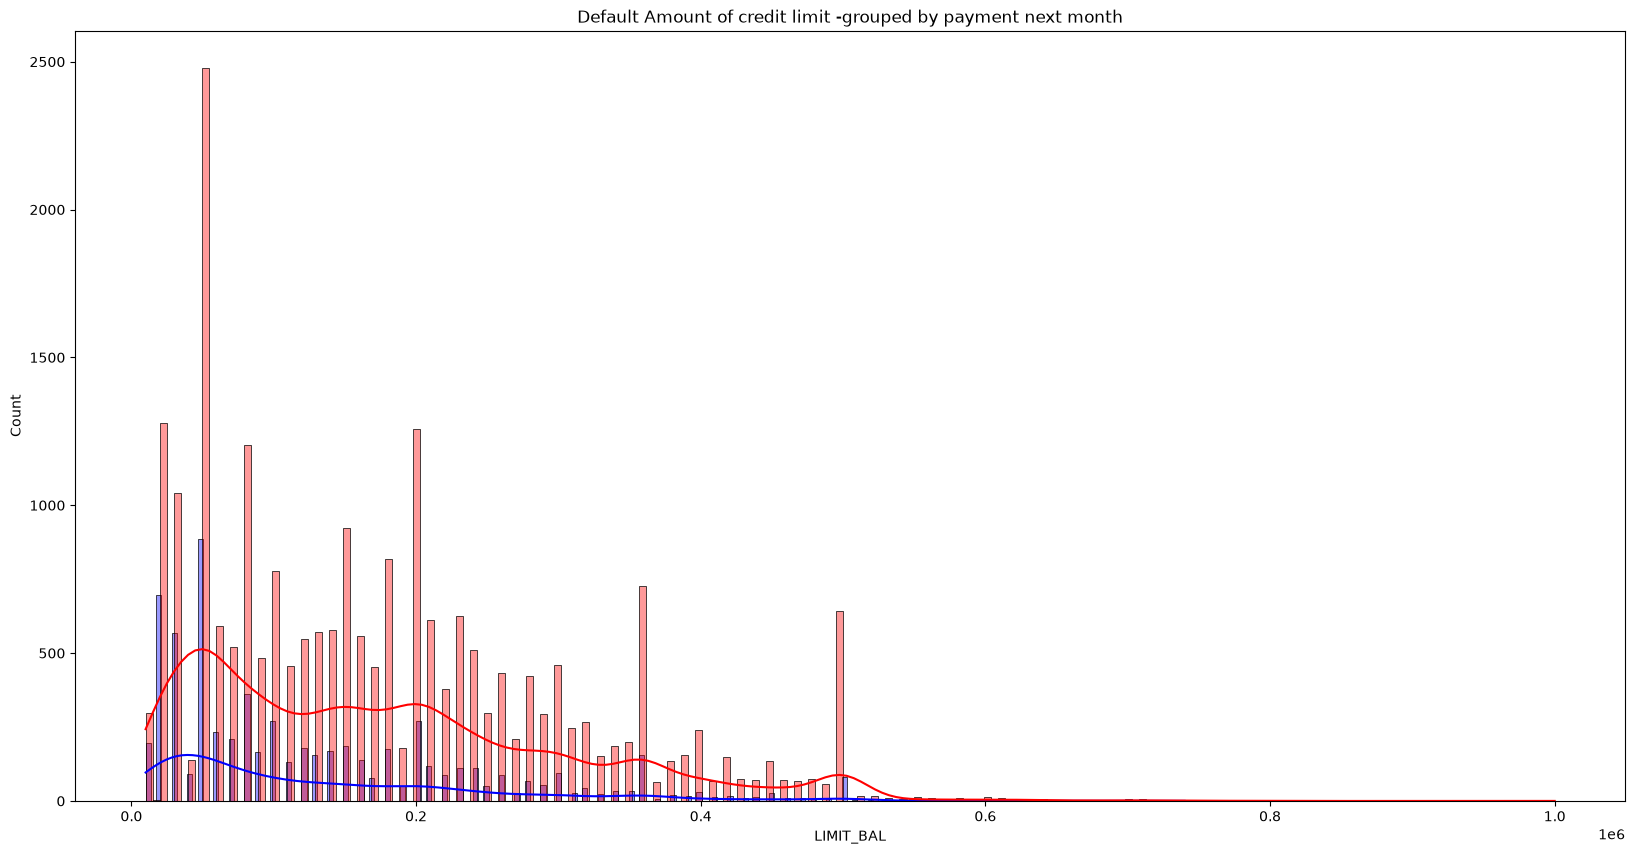

In [178]:
class_0= credit_df.loc[credit_df['default.payment.next.month']==0]['LIMIT_BAL']
class_1= credit_df.loc[credit_df['default.payment.next.month']==1]['LIMIT_BAL']

plt.figure(figsize=(20,10))
plt.title('Default Amount of credit limit -grouped by payment next month')
sns.histplot(class_1, kde= True, bins=200, color='blue',alpha=0.4)
sns.histplot(class_0, kde= True, bins=200, color='red',alpha=0.4)
plt.show()

In [179]:
credit_df.drop(columns=['ID'], axis='columns')

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [180]:
credit_df.sample()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
328,329,340000.0,1,2,1,55,-2,-1,-1,-2,...,2190.0,24599.0,7416.0,44665.0,8321.0,2190.0,24599.0,7416.0,77195.0,0


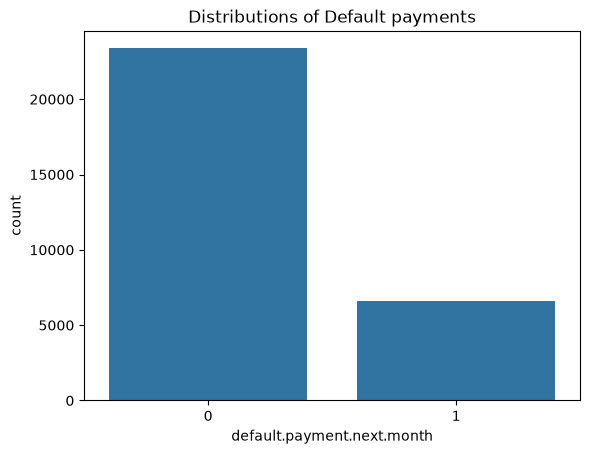

In [181]:
sns.countplot(x= 'default.payment.next.month', data= credit_df)
plt.title('Distributions of Default payments')
plt.show()

### 6. Class imbalance 

##### Impacts:
1. accuracy can be misleading eg: here about 80% dont default so if your model just guesses all 0s, it'll be correct for 80% of the time
2. Model favors majority class so here recall 0=97, while 1=23. 
3. accuracy hides poor minority performance thus ROC-auc, precision, recall becomes necessary metrics in comparison

##### Solutions:
1. Threshold changes to catch sort out which type error we want to make fewer. in this case type 2 so threshold decreased to 0.2
2. Use proper evaluation metrics. in this case, confusion matrix, ROC-AUC, recall and F1 score.

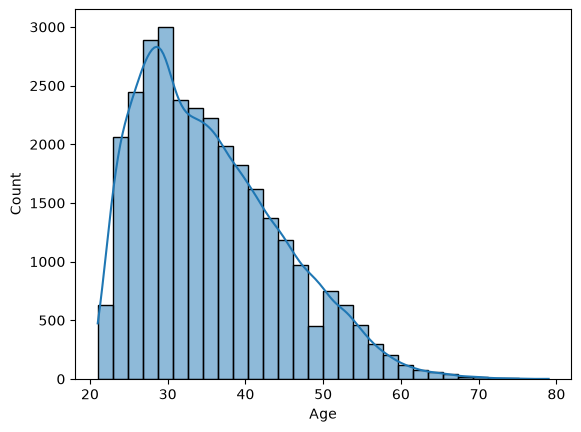

In [182]:
#Balancing dataset
sns.histplot(credit_df['AGE'],bins=30,kde=True)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

<Axes: >

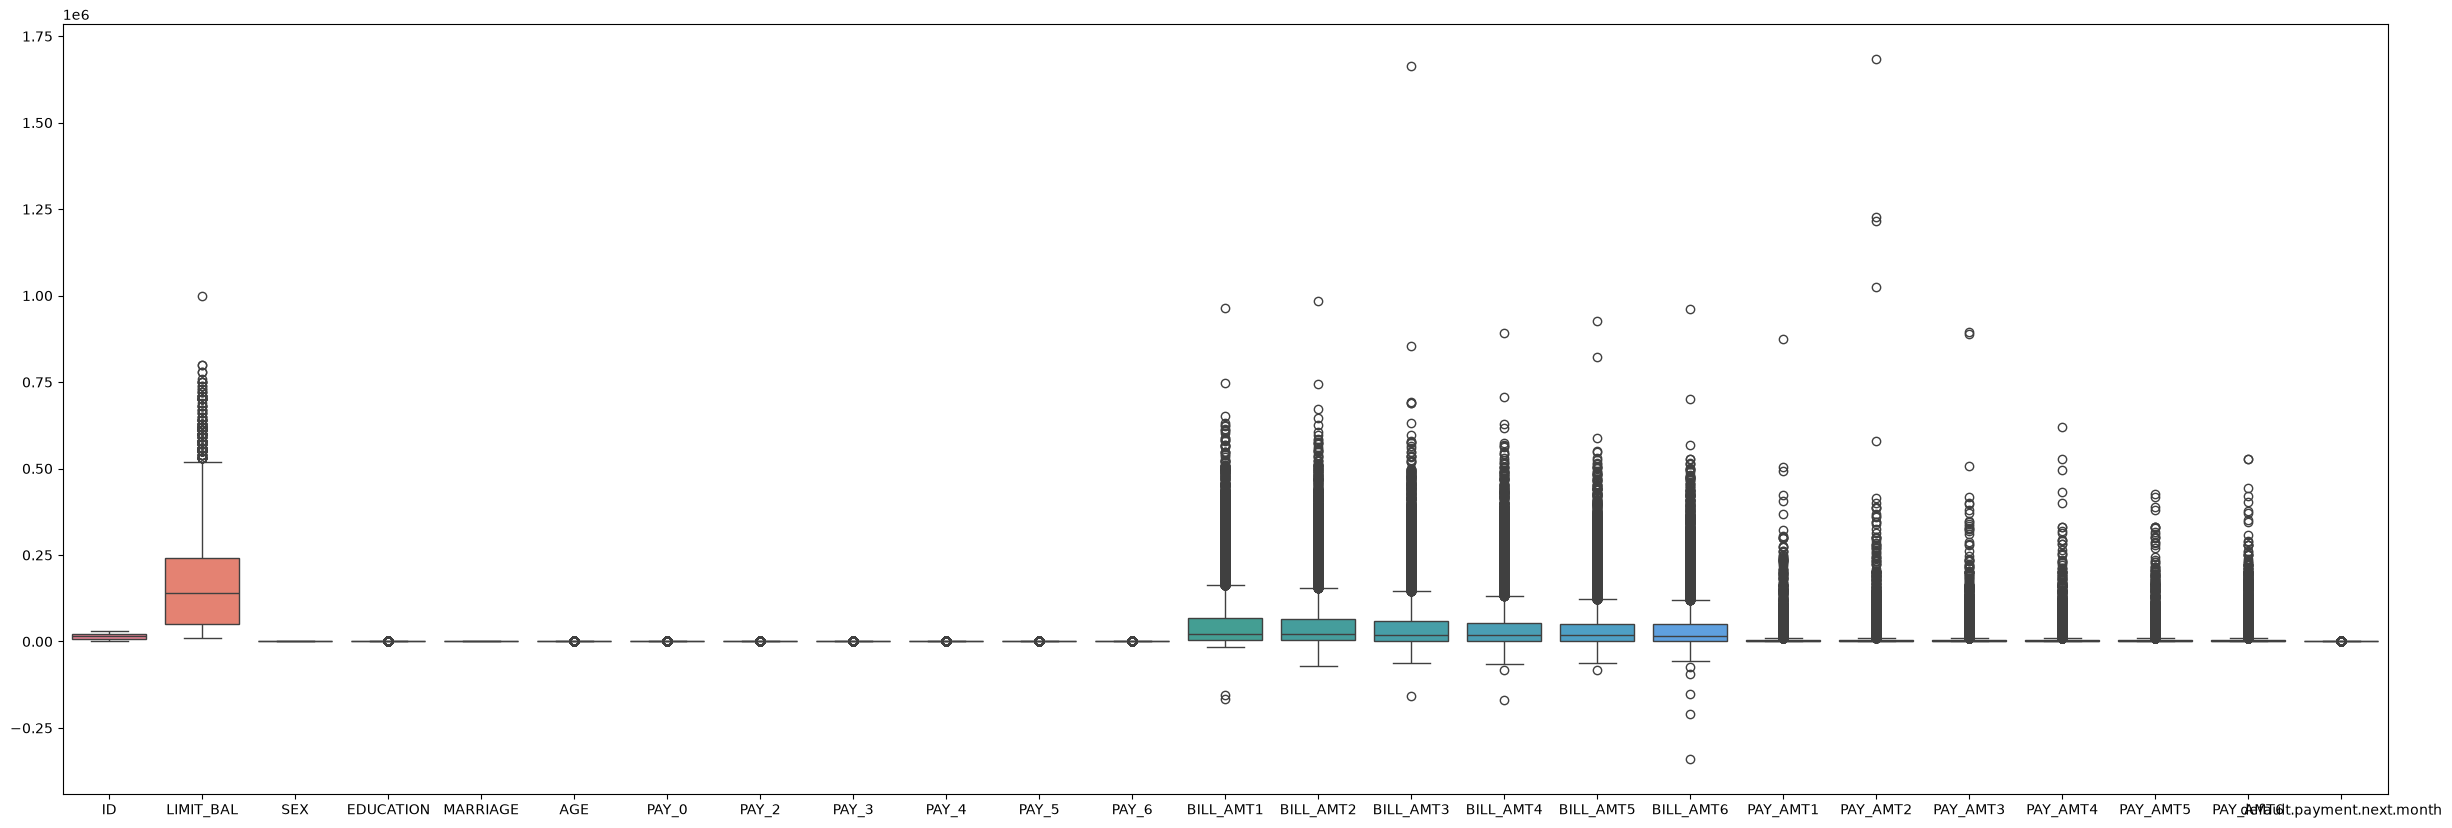

In [183]:
#normalize
plt.figure(figsize=(30,10))
sns.boxplot(data=credit_df)

### So many outliers, which means they all cant be removed

### Separate features and target variable


In [184]:
X= credit_df.drop('default.payment.next.month', axis=1) 
y= credit_df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


In [185]:
#Modeling for ML
# model= LogisticRegression(class_weight='balanced',
#     max_iter=1000)
model= LogisticRegression()

model.fit(X_train_scaled, y_train)
y_pred= model.predict(X_test_scaled)

In [186]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [187]:
accuracy= accuracy_score(y_test, y_pred)
accuracy

0.8201666666666667

In [188]:
report= classification_report(y_test,y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.83      0.97      0.90      4733
           1       0.71      0.25      0.37      1267

    accuracy                           0.82      6000
   macro avg       0.77      0.61      0.63      6000
weighted avg       0.80      0.82      0.78      6000



### Odds- ratio ranked v

In [189]:
odds_ratios = pd.Series(
    np.exp(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(odds_ratios)

print("Here the highest odds ratio is for the LIMIT_BAL column, which means that as the credit limit increases, the likelihood of defaulting on payment decreases. The lowest odds ratio is for the PAY_0 column, which means that as the payment status in September 2005 increases (i.e., the customer is more delinquent), the likelihood of defaulting on payment increases.")

PAY_0        1.924207
BILL_AMT3    1.156557
PAY_3        1.095943
PAY_2        1.087729
AGE          1.075369
BILL_AMT6    1.073207
BILL_AMT2    1.064737
PAY_5        1.029448
PAY_4        1.020085
PAY_6        1.016940
BILL_AMT5    1.014852
ID           0.975536
BILL_AMT4    0.969162
SEX          0.956307
PAY_AMT6     0.952600
MARRIAGE     0.944268
PAY_AMT5     0.943153
EDUCATION    0.935001
PAY_AMT3     0.933191
PAY_AMT4     0.926627
LIMIT_BAL    0.894685
PAY_AMT1     0.824081
PAY_AMT2     0.776848
BILL_AMT1    0.712173
dtype: float64
Here the highest odds ratio is for the LIMIT_BAL column, which means that as the credit limit increases, the likelihood of defaulting on payment decreases. The lowest odds ratio is for the PAY_0 column, which means that as the payment status in September 2005 increases (i.e., the customer is more delinquent), the likelihood of defaulting on payment increases.


In [190]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))

In [191]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Testing different thresholds to see how it affects the classification report
# for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
#     y_pred = (y_prob >= threshold).astype(int)
    
#     print(f"\nThreshold: {threshold}")
#     print(classification_report(y_test, y_pred))

threshold = 0.2 #0.3 proved to be the sweet spot
y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred))
# from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)
print("\n\n")
print(y_train.value_counts())
print(y_test.value_counts())


              precision    recall  f1-score   support

           0       0.88      0.58      0.70      4733
           1       0.31      0.70      0.43      1267

    accuracy                           0.61      6000
   macro avg       0.60      0.64      0.57      6000
weighted avg       0.76      0.61      0.65      6000

AUC: 0.7247247699614006



default.payment.next.month
0    18631
1     5369
Name: count, dtype: int64
default.payment.next.month
0    4733
1    1267
Name: count, dtype: int64


### Since recall=70, this model can catch 70% of defaulters and miss only about 30%

In [192]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2766 1967]
 [ 376  891]]


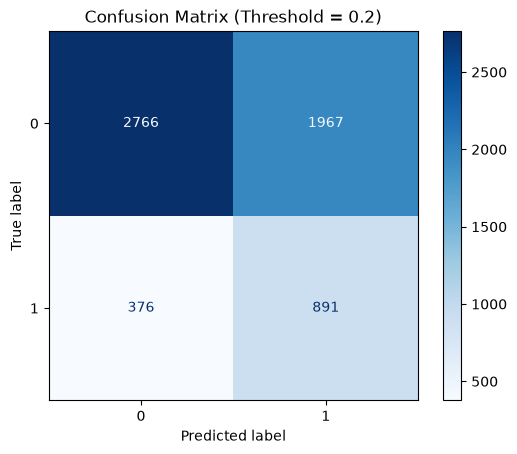

In [193]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title(f'Confusion Matrix (Threshold = {threshold})')
plt.show()

## Question 3: Hyperparameter Tuning & Model Optimization

### Scenario

After deploying your classification model, stakeholders ask you to **improve performance** without changing the dataset.

You decide to optimize the model using systematic hyperparameter search techniques.

### Dataset

Reuse the dataset from **Question 2**.

### Tasks

1. Explain the difference between **parameters** and **hyperparameters**.
2. Train a **baseline Logistic Regression** model.
3. Apply **GridSearchCV** to tune hyperparameters (`C`, `penalty`, `solver`).
4. Apply **RandomizedSearchCV** and compare results.
5. Compare performance before and after tuning.
6. Discuss trade-offs between **computational cost** and **model performance**.

#### 1. Parameters vs. hyperparameters

Parameters are learned by the model during training.

For Logistic Regression, examples include:

Coefficients (model.coef_)
Intercept (model.intercept_)

Hyperparameters are set by us before training and control how the model learns.

For Logistic Regression:

C
penalty
solver

In [194]:
baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)
baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

In [195]:
print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

print("Baseline ROC-AUC:",
      roc_auc_score(y_test, baseline_prob))

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.6933333333333334
Baseline ROC-AUC: 0.7247794666109472

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4733
           1       0.37      0.64      0.47      1267

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.77      0.69      0.72      6000



In [196]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

In [198]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

d:\study material\Project\DSandML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

In [199]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV ROC-AUC:
0.723440015162501


In [200]:
best_grid_model = grid_search.best_estimator_

In [201]:
grid_pred = best_grid_model.predict(X_test_scaled)
grid_prob = best_grid_model.predict_proba(X_test_scaled)[:, 1]

print("Test ROC-AUC:",
      roc_auc_score(y_test, grid_prob))

print("\nClassification Report:")
print(classification_report(y_test, grid_pred))

Test ROC-AUC: 0.7248041468064744

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4733
           1       0.37      0.64      0.47      1267

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.77      0.69      0.72      6000



In [203]:
param_distributions = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=50
)

random_search.fit(X_train_scaled, y_train)

d:\study material\Project\DSandML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",50
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``b

In [204]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': 1000}

Best CV ROC-AUC:
0.7234399652503536


In [205]:
best_random_model = random_search.best_estimator_

In [206]:
random_pred = best_random_model.predict(X_test_scaled)
random_prob = best_random_model.predict_proba(X_test_scaled)[:, 1]

print("Test ROC-AUC:",
      roc_auc_score(y_test, random_prob))

print("\nClassification Report:")
print(classification_report(y_test, random_pred))


Test ROC-AUC: 0.7248031462580071

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4733
           1       0.37      0.64      0.47      1267

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.77      0.69      0.72      6000



In [208]:
baseline_auc = roc_auc_score(y_test, baseline_prob)

grid_auc = roc_auc_score(y_test, grid_prob)

random_auc = roc_auc_score(y_test, random_prob)

print("Model Comparison")
print(f"Baseline ROC-AUC:  {baseline_auc:.4f}")
print(f"GridSearch ROC-AUC: {grid_auc:.4f}")
print(f"Randomized ROC-AUC: {random_auc:.4f}")

Model Comparison
Baseline ROC-AUC:  0.7248
GridSearch ROC-AUC: 0.7248
Randomized ROC-AUC: 0.7248


In [209]:
#Compare recall for class 1
baseline_recall = recall_score(y_test, baseline_pred)
grid_recall = recall_score(y_test, grid_pred)
random_recall = recall_score(y_test, random_pred)

print(f"Baseline Recall:    {baseline_recall:.4f}")
print(f"GridSearch Recall:  {grid_recall:.4f}")
print(f"Randomized Recall:  {random_recall:.4f}")

Baseline Recall:    0.6417
GridSearch Recall:  0.6417
Randomized Recall:  0.6417


##### GridSearchCV:

-More exhaustive
-Good when the hyperparameter space is small
-Can find the best combination within the specified grid
-More computationally expensive

##### RandomizedSearchCV:

-Faster for large search spaces
-Doesn't test every combination
-Can explore a wider range of values
-May find a very good solution without exhaustive search

Since the search space is relatively small. gridSearch is reasonable